# MoLE — Mixture-of-Linear-Experts Forecasting — lon / lat / alt

This notebook contains **two MoLE implementations** on the `italy_flights_20k` dataset.

## Part 1 — Custom MoLE (original implementation)
Implements MoLE (arXiv:2312.06786) from scratch with shared (non-individual) DLinear experts
and a learned router MLP.

## Part 2 — TSL-faithful MoLE
Re-implements MoLE using the exact components from the
[Time-Series-Library (thuml/Time-Series-Library)](https://github.com/thuml/Time-Series-Library):
- **`series_decomp`**: front/end-padded moving average (as in `layers/Autoformer_EncDec.py`)
- **`DLinear` expert**: `individual=True` per-channel linear layers initialized to `1/seq_len`
  (as in `models/DLinear.py`)
- Same router MLP + softmax-weighted mixture.

Note: the TSL repo has no pip package — model code is inlined directly.

**Common settings**
- Input: 60 time-steps of `[lon, lat, alt]`  |  Output: next 12 time-steps
- Min flight length: 200 steps  |  Freq: 10 s  |  Train/test: 70 % / 30 %

In [45]:
# Uncomment if darts is not yet installed:
# !pip install darts

---
# PART 1 — Custom MoLE
---
## 0. Imports & device

In [46]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mse, mae

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = (
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(f"Using device: {DEVICE}")

Using device: mps


## 1. Load data

In [47]:
df = pd.read_parquet("../data/italy_flights_20k.parquet")
df["datetime"] = pd.to_datetime(df["timestamp"], unit="s")

print(f"Total rows: {len(df):,}")
print(f"Unique flights: {df['track_id'].nunique():,}")
df.head()

Total rows: 2,493,533
Unique flights: 13,919


,track_id,lon,lat,alt,timestamp,datetime
0,000001_2021-01-25,36.204828,31.774975,4732.02,1611588050,2021-01-25 15:20:50
1,000001_2021-01-25,36.215552,31.771251,4792.98,1611588060,2021-01-25 15:21:00
2,000001_2021-01-25,36.225934,31.767666,4853.94,1611588070,2021-01-25 15:21:10
3,000001_2021-01-25,36.236920,31.763942,4922.52,1611588080,2021-01-25 15:21:20
4,000001_2021-01-25,36.247128,31.760513,4998.72,1611588090,2021-01-25 15:21:30


## 2. Build per-flight TimeSeries objects

In [48]:
MIN_LENGTH = 200   # drop flights shorter than this
FREQ = "10s"       # 10-second sampling frequency

series_list = []
skipped = 0

for track_id, g in df.groupby("track_id"):
    g = g.sort_values("datetime").drop_duplicates(subset="datetime")

    if len(g) < MIN_LENGTH:
        skipped += 1
        continue

    try:
        ts = TimeSeries.from_dataframe(
            g,
            time_col="datetime",
            value_cols=["lon", "lat", "alt"],
            freq=FREQ,
            fill_missing_dates=True,
        )
        # Skip series with NaNs after freq enforcement
        if np.isnan(ts.values()).any():
            skipped += 1
            continue
        series_list.append(ts.astype(np.float32))
    except Exception:
        skipped += 1

print(f"Kept: {len(series_list)} flights  |  Skipped: {skipped}")

Kept: 4967 flights  |  Skipped: 8952


## 3. Scale & split

In [49]:
TRAIN_FRAC = 0.7

train_series_scaled = []
test_series_scaled  = []
scalers = []

for ts in series_list:
    train_raw, test_raw = ts.split_before(TRAIN_FRAC)

    scaler = Scaler()
    train_sc = scaler.fit_transform(train_raw)
    test_sc  = scaler.transform(test_raw)

    train_series_scaled.append(train_sc)
    test_series_scaled.append(test_sc)
    scalers.append(scaler)

print(f"Train series: {len(train_series_scaled)}  |  Test series: {len(test_series_scaled)}")

Train series: 4967  |  Test series: 4967


## 4. Custom MoLE model definition

### Architecture

Each **expert** is a DLinear-style model:
1. Moving-average decomposition (center-padded AvgPool1d) splits input into *trend* and *remainder*.
2. Two separate linear layers map each component independently `input_len → output_len`.
3. Expert output = trend_out + remainder_out.

The **router** is a small MLP: `(input_len × n_features) → 64 → n_experts` + softmax.

Final prediction = softmax-weighted sum of expert outputs. Trained end-to-end with MSE.

In [50]:
INPUT_LEN  = 60   # context length
OUTPUT_LEN = 12   # forecast horizon
N_FEATURES = 3    # lon, lat, alt
N_EXPERTS  = 4    # number of linear experts
MA_KERNEL  = 25   # moving-average kernel size for decomposition
N_EPOCHS   = 10
BATCH_SIZE = 512
LR         = 1e-3


class MovingAvgDecomp(nn.Module):
    """Decompose into trend (moving average) and remainder — center-padded."""

    def __init__(self, kernel_size: int):
        super().__init__()
        self.avg = nn.AvgPool1d(
            kernel_size=kernel_size,
            stride=1,
            padding=(kernel_size - 1) // 2,
        )

    def forward(self, x: torch.Tensor):
        # x: (B, L, C)
        x_t = x.permute(0, 2, 1)          # (B, C, L)
        trend = self.avg(x_t)[:, :, :x.shape[1]]  # trim to L
        trend = trend.permute(0, 2, 1)    # (B, L, C)
        return trend, x - trend


class DLinearExpert(nn.Module):
    """One shared DLinear expert (channel-independent linear layers)."""

    def __init__(self, input_len: int, output_len: int, n_features: int, kernel_size: int):
        super().__init__()
        self.decomp = MovingAvgDecomp(kernel_size)
        self.linear_trend     = nn.Linear(input_len, output_len)
        self.linear_remainder = nn.Linear(input_len, output_len)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, L, C)
        trend, remainder = self.decomp(x)
        t_out = self.linear_trend(trend.permute(0, 2, 1))          # (B, C, pred)
        r_out = self.linear_remainder(remainder.permute(0, 2, 1))  # (B, C, pred)
        return (t_out + r_out).permute(0, 2, 1)  # (B, pred, C)


class Router(nn.Module):
    """Maps flattened input to softmax expert weights."""

    def __init__(self, input_len: int, n_features: int, n_experts: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_len * n_features, 64),
            nn.ReLU(),
            nn.Linear(64, n_experts),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.softmax(self.net(x.flatten(start_dim=1)), dim=-1)  # (B, E)


class MoLE(nn.Module):
    """Mixture-of-Linear-Experts (MoLE) — custom implementation."""

    def __init__(self, input_len, output_len, n_features, n_experts, kernel_size):
        super().__init__()
        self.experts = nn.ModuleList([
            DLinearExpert(input_len, output_len, n_features, kernel_size)
            for _ in range(n_experts)
        ])
        self.router = Router(input_len, n_features, n_experts)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        weights = self.router(x)                                    # (B, E)
        expert_outs = torch.stack([e(x) for e in self.experts], dim=-1)  # (B, pred, C, E)
        w = weights[:, None, None, :]                               # (B, 1, 1, E)
        return (expert_outs * w).sum(dim=-1)                        # (B, pred, C)


model = MoLE(
    input_len=INPUT_LEN, output_len=OUTPUT_LEN,
    n_features=N_FEATURES, n_experts=N_EXPERTS, kernel_size=MA_KERNEL,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Custom MoLE  |  experts={N_EXPERTS}  |  trainable params={total_params:,}")

Custom MoLE  |  experts=4  |  trainable params=17,700


## 5. Dataset & DataLoader

In [51]:
class FlightWindowDataset(Dataset):
    """Sliding-window (context, target) pairs from a list of Darts TimeSeries."""

    def __init__(self, series_list, input_len: int, output_len: int):
        self.samples = []
        for ts in series_list:
            vals = ts.values().astype(np.float32)   # (T, C)
            T = len(vals)
            for start in range(0, T - input_len - output_len + 1):
                x = vals[start : start + input_len]
                y = vals[start + input_len : start + input_len + output_len]
                self.samples.append((x, y))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y = self.samples[idx]
        return torch.tensor(x), torch.tensor(y)


train_dataset = FlightWindowDataset(train_series_scaled, INPUT_LEN, OUTPUT_LEN)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
print(f"Training windows: {len(train_dataset):,}")

Training windows: 642,970


## 6. Train Custom MoLE

In [52]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

model.train()
for epoch in range(1, N_EPOCHS + 1):
    epoch_loss = 0.0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(x_batch), y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(x_batch)
    print(f"Epoch {epoch:>2}/{N_EPOCHS}  |  train MSE = {epoch_loss / len(train_dataset):.6f}")

print("Training complete.")

Epoch  1/10  |  train MSE = 0.017575
Epoch  2/10  |  train MSE = 0.012092
Epoch  3/10  |  train MSE = 0.011626
Epoch  4/10  |  train MSE = 0.011212
Epoch  5/10  |  train MSE = 0.010938
Epoch  6/10  |  train MSE = 0.010755
Epoch  7/10  |  train MSE = 0.010628
Epoch  8/10  |  train MSE = 0.010548
Epoch  9/10  |  train MSE = 0.010476
Epoch 10/10  |  train MSE = 0.010416
Training complete.


## 7. Evaluate on test set

In [53]:
def evaluate_model(mdl, n_samples=200):
    """Return mean MSE and MAE over n_samples randomly chosen test flights."""
    indices = random.sample(range(len(test_series_scaled)), n_samples)
    mdl.eval()
    mse_scores, mae_scores = [], []
    with torch.no_grad():
        for i in indices:
            train_sc = train_series_scaled[i]
            test_sc  = test_series_scaled[i]
            ctx = train_sc[-INPUT_LEN:].values().astype(np.float32)
            x   = torch.tensor(ctx).unsqueeze(0).to(DEVICE)
            pred_vals = mdl(x).squeeze(0).cpu().numpy()   # (12, 3)
            actual = test_sc[:OUTPUT_LEN]
            if len(actual) < OUTPUT_LEN:
                continue
            forecast_ts = TimeSeries.from_times_and_values(
                times=actual.time_index, values=pred_vals,
                columns=["lon", "lat", "alt"],
            )
            mse_scores.append(mse(actual, forecast_ts))
            mae_scores.append(mae(actual, forecast_ts))
    return np.mean(mse_scores), np.mean(mae_scores), len(mse_scores)


m, a, n = evaluate_model(model)
print(f"[Custom MoLE]  Mean MSE = {m:.6f}  |  Mean MAE = {a:.6f}  ({n} flights)")

[Custom MoLE]  Mean MSE = 322.891968  |  Mean MAE = 0.288437  (200 flights)


## 8. Per-feature time-series visualisation

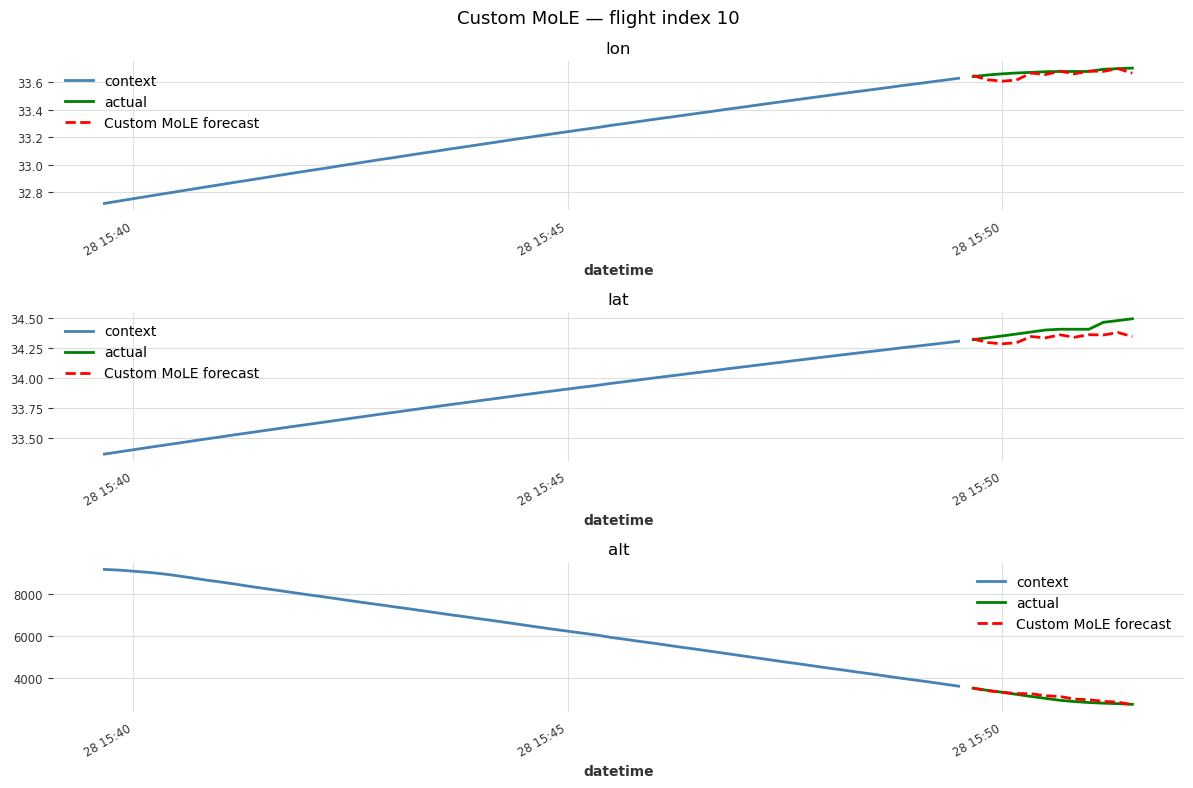

In [54]:
def plot_forecast(mdl, sample_idx, model_label="MoLE"):
    train_sc = train_series_scaled[sample_idx]
    test_sc  = test_series_scaled[sample_idx]
    scaler   = scalers[sample_idx]
    context  = train_sc[-INPUT_LEN:]

    mdl.eval()
    with torch.no_grad():
        x = torch.tensor(context.values().astype(np.float32)).unsqueeze(0).to(DEVICE)
        pred_sc = mdl(x).squeeze(0).cpu().numpy()

    actual_sc   = test_sc[:OUTPUT_LEN]
    forecast_sc = TimeSeries.from_times_and_values(
        times=actual_sc.time_index, values=pred_sc, columns=["lon", "lat", "alt"],
    )
    actual_orig   = scaler.inverse_transform(actual_sc)
    forecast_orig = scaler.inverse_transform(forecast_sc)
    context_orig  = scaler.inverse_transform(context)
    return context_orig, actual_orig, forecast_orig


SAMPLE_IDX = 10
ctx_orig, act_orig, fct_orig = plot_forecast(model, SAMPLE_IDX, "Custom MoLE")

feature_names = ["lon", "lat", "alt"]
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
for ax, feat in zip(axes, feature_names):
    ctx_orig[feat].plot(ax=ax, label="context", color="steelblue")
    act_orig[feat].plot(ax=ax, label="actual", color="green")
    fct_orig[feat].plot(ax=ax, label="Custom MoLE forecast", color="red", linestyle="--")
    ax.set_title(feat)
    ax.legend()

plt.suptitle(f"Custom MoLE — flight index {SAMPLE_IDX}", fontsize=13)
plt.tight_layout()
plt.show()

## 9. 2-D trajectory plot (lon vs lat)

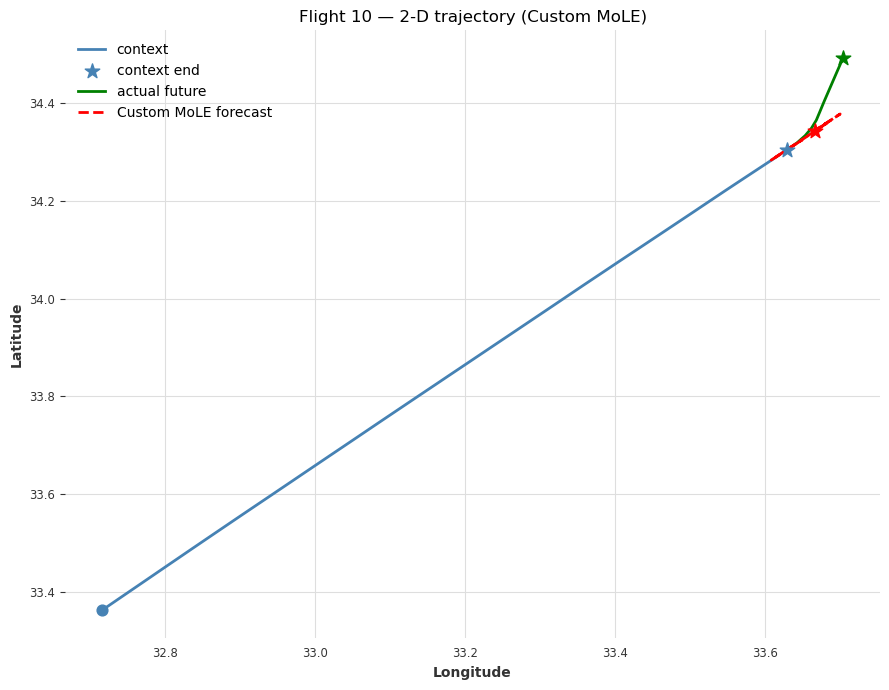

In [55]:
def plot_2d(ctx_orig, act_orig, fct_orig, sample_idx, model_label="MoLE"):
    ctx_vals = ctx_orig.values()
    act_vals = act_orig.values()
    fct_vals = fct_orig.values()

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.plot(ctx_vals[:, 0], ctx_vals[:, 1], color="steelblue", lw=2, label="context")
    ax.scatter(ctx_vals[0, 0], ctx_vals[0, 1], color="steelblue", s=60, zorder=5)
    ax.scatter(ctx_vals[-1, 0], ctx_vals[-1, 1], color="steelblue", s=120, marker="*", zorder=5, label="context end")
    ax.plot([ctx_vals[-1, 0]] + list(act_vals[:, 0]),
            [ctx_vals[-1, 1]] + list(act_vals[:, 1]),
            color="green", lw=2, label="actual future")
    ax.scatter(act_vals[-1, 0], act_vals[-1, 1], color="green", s=120, marker="*", zorder=5)
    ax.plot([ctx_vals[-1, 0]] + list(fct_vals[:, 0]),
            [ctx_vals[-1, 1]] + list(fct_vals[:, 1]),
            color="red", lw=2, linestyle="--", label=f"{model_label} forecast")
    ax.scatter(fct_vals[-1, 0], fct_vals[-1, 1], color="red", s=120, marker="*", zorder=5)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"Flight {sample_idx} — 2-D trajectory ({model_label})")
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_2d(ctx_orig, act_orig, fct_orig, SAMPLE_IDX, "Custom MoLE")

## 10. 3-D trajectory plot (lon, lat, alt)

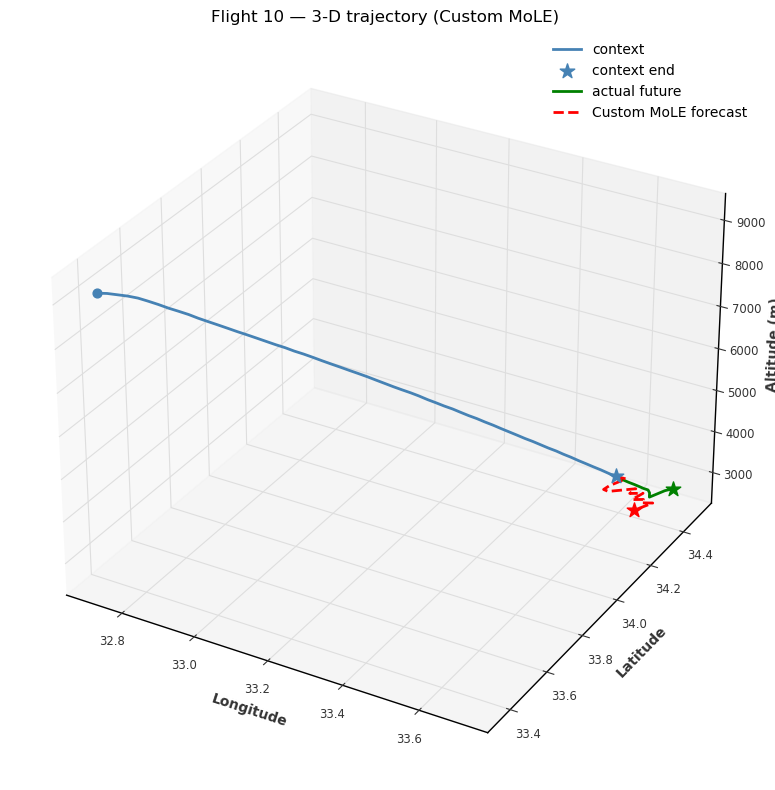

In [56]:
def plot_3d(ctx_orig, act_orig, fct_orig, sample_idx, model_label="MoLE"):
    ctx_vals = ctx_orig.values()
    act_vals = act_orig.values()
    fct_vals = fct_orig.values()

    fig = plt.figure(figsize=(11, 8))
    ax3 = fig.add_subplot(111, projection="3d")
    ax3.plot(ctx_vals[:, 0], ctx_vals[:, 1], ctx_vals[:, 2], color="steelblue", lw=2, label="context")
    ax3.scatter(*ctx_vals[0], color="steelblue", s=40, zorder=5)
    ax3.scatter(*ctx_vals[-1], color="steelblue", s=120, marker="*", zorder=5, label="context end")
    ax3.plot([ctx_vals[-1, 0]] + list(act_vals[:, 0]),
             [ctx_vals[-1, 1]] + list(act_vals[:, 1]),
             [ctx_vals[-1, 2]] + list(act_vals[:, 2]),
             color="green", lw=2, label="actual future")
    ax3.scatter(*act_vals[-1], color="green", s=120, marker="*", zorder=5)
    ax3.plot([ctx_vals[-1, 0]] + list(fct_vals[:, 0]),
             [ctx_vals[-1, 1]] + list(fct_vals[:, 1]),
             [ctx_vals[-1, 2]] + list(fct_vals[:, 2]),
             color="red", lw=2, linestyle="--", label=f"{model_label} forecast")
    ax3.scatter(*fct_vals[-1], color="red", s=120, marker="*", zorder=5)
    ax3.set_xlabel("Longitude")
    ax3.set_ylabel("Latitude")
    ax3.set_zlabel("Altitude (m)")
    ax3.set_title(f"Flight {sample_idx} — 3-D trajectory ({model_label})")
    ax3.legend()
    plt.tight_layout()
    plt.show()


plot_3d(ctx_orig, act_orig, fct_orig, SAMPLE_IDX, "Custom MoLE")

---
# PART 2 — TSL-faithful MoLE

This section re-implements MoLE using the **exact building blocks** from the
[thuml/Time-Series-Library](https://github.com/thuml/Time-Series-Library) repository.

There is **no pip package** for TSL — the model code is inlined below directly from the repo.

### Key differences from Part 1

| | Custom MoLE (Part 1) | TSL-faithful MoLE (Part 2) |
|---|---|---|
| `series_decomp` | Center-padded `AvgPool1d` | **Front/end replicate-padding** (exact TSL `Autoformer_EncDec.py`) |
| Linear layers | Shared across channels | **Per-channel** (`individual=True`), init = `1/seq_len` (exact TSL `DLinear.py`) |
| Router | Same MLP | Same MLP |

### Source references
- `series_decomp`: `layers/Autoformer_EncDec.py` — [view on GitHub](https://github.com/thuml/Time-Series-Library/blob/main/layers/Autoformer_EncDec.py)
- `DLinear` expert: `models/DLinear.py` — [view on GitHub](https://github.com/thuml/Time-Series-Library/blob/main/models/DLinear.py)

## 11. TSL-faithful MoLE model definition

The two TSL components below are copied verbatim from the repo (simplified to forecasting task only).

In [57]:
# -----------------------------------------------------------------------
# TSL component 1: moving_avg + series_decomp
# Source: layers/Autoformer_EncDec.py
# https://github.com/thuml/Time-Series-Library/blob/main/layers/Autoformer_EncDec.py
# -----------------------------------------------------------------------

class TSL_MovingAvg(nn.Module):
    """Moving average block — replicates first/last value as padding (TSL exact)."""

    def __init__(self, kernel_size: int, stride: int = 1):
        super().__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, L, C) — same convention as TSL input to decomp
        pad = (self.kernel_size - 1) // 2
        front = x[:, 0:1, :].repeat(1, pad, 1)   # replicate first value
        end   = x[:, -1:, :].repeat(1, pad, 1)   # replicate last value
        x_pad = torch.cat([front, x, end], dim=1) # (B, L + 2*pad, C)
        # AvgPool1d expects (B, C, L)
        out = self.avg(x_pad.permute(0, 2, 1)).permute(0, 2, 1)  # (B, L, C)
        return out


class TSL_SeriesDecomp(nn.Module):
    """Series decomposition block (TSL exact)."""

    def __init__(self, kernel_size: int):
        super().__init__()
        self.moving_avg = TSL_MovingAvg(kernel_size)

    def forward(self, x: torch.Tensor):
        trend = self.moving_avg(x)
        remainder = x - trend
        return remainder, trend   # (seasonal, trend) — matches TSL return order


# -----------------------------------------------------------------------
# TSL component 2: DLinear expert (individual=True)
# Source: models/DLinear.py
# https://github.com/thuml/Time-Series-Library/blob/main/models/DLinear.py
# -----------------------------------------------------------------------

class TSL_DLinearExpert(nn.Module):
    """
    DLinear expert with individual=True per-channel linear layers.
    Weights initialised to 1/seq_len (exact TSL default).
    """

    def __init__(self, input_len: int, output_len: int, n_features: int, kernel_size: int):
        super().__init__()
        self.decomp = TSL_SeriesDecomp(kernel_size)
        self.channels = n_features

        # Per-channel linear layers (individual=True)
        self.Linear_Seasonal = nn.ModuleList()
        self.Linear_Trend    = nn.ModuleList()
        for _ in range(self.channels):
            ls = nn.Linear(input_len, output_len)
            lt = nn.Linear(input_len, output_len)
            # TSL initialisation: weight = 1/seq_len
            ls.weight = nn.Parameter(
                (1 / input_len) * torch.ones([output_len, input_len]))
            lt.weight = nn.Parameter(
                (1 / input_len) * torch.ones([output_len, input_len]))
            self.Linear_Seasonal.append(ls)
            self.Linear_Trend.append(lt)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, L, C)
        seasonal, trend = self.decomp(x)            # each (B, L, C)
        s = seasonal.permute(0, 2, 1)               # (B, C, L)
        t = trend.permute(0, 2, 1)                  # (B, C, L)

        s_out = torch.zeros(s.shape[0], self.channels, self.Linear_Seasonal[0].out_features,
                            dtype=s.dtype, device=s.device)
        t_out = torch.zeros_like(s_out)
        for i in range(self.channels):
            s_out[:, i, :] = self.Linear_Seasonal[i](s[:, i, :])
            t_out[:, i, :] = self.Linear_Trend[i](t[:, i, :])

        return (s_out + t_out).permute(0, 2, 1)     # (B, pred, C)


# -----------------------------------------------------------------------
# TSL-faithful MoLE (same router as Part 1)
# -----------------------------------------------------------------------

class MoLE_TSL(nn.Module):
    """MoLE built from TSL's exact series_decomp and DLinear(individual=True)."""

    def __init__(self, input_len, output_len, n_features, n_experts, kernel_size):
        super().__init__()
        self.experts = nn.ModuleList([
            TSL_DLinearExpert(input_len, output_len, n_features, kernel_size)
            for _ in range(n_experts)
        ])
        self.router = Router(input_len, n_features, n_experts)  # reuse Part-1 Router

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        weights = self.router(x)                                        # (B, E)
        expert_outs = torch.stack([e(x) for e in self.experts], dim=-1) # (B, pred, C, E)
        return (expert_outs * weights[:, None, None, :]).sum(dim=-1)    # (B, pred, C)


model_tsl = MoLE_TSL(
    input_len=INPUT_LEN, output_len=OUTPUT_LEN,
    n_features=N_FEATURES, n_experts=N_EXPERTS, kernel_size=MA_KERNEL,
).to(DEVICE)

total_params_tsl = sum(p.numel() for p in model_tsl.parameters() if p.requires_grad)
print(f"TSL-faithful MoLE  |  experts={N_EXPERTS}  |  trainable params={total_params_tsl:,}")

TSL-faithful MoLE  |  experts=4  |  trainable params=29,412


## 12. Train TSL-faithful MoLE

In [58]:
# train_loader is reused from Part 1 (same dataset, same windows)
criterion_tsl = nn.MSELoss()
optimizer_tsl = optim.Adam(model_tsl.parameters(), lr=LR)

model_tsl.train()
for epoch in range(1, N_EPOCHS + 1):
    epoch_loss = 0.0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_tsl.zero_grad()
        loss = criterion_tsl(model_tsl(x_batch), y_batch)
        loss.backward()
        optimizer_tsl.step()
        epoch_loss += loss.item() * len(x_batch)
    print(f"Epoch {epoch:>2}/{N_EPOCHS}  |  train MSE = {epoch_loss / len(train_dataset):.6f}")

print("Training complete.")

Epoch  1/10  |  train MSE = 0.012668
Epoch  2/10  |  train MSE = 0.011467
Epoch  3/10  |  train MSE = 0.011144
Epoch  4/10  |  train MSE = 0.010908
Epoch  5/10  |  train MSE = 0.010762
Epoch  6/10  |  train MSE = 0.010670
Epoch  7/10  |  train MSE = 0.010584
Epoch  8/10  |  train MSE = 0.010515
Epoch  9/10  |  train MSE = 0.010429
Epoch 10/10  |  train MSE = 0.010362
Training complete.


## 13. Evaluate & compare both models

In [59]:
m_tsl, a_tsl, n_tsl = evaluate_model(model_tsl)  # reuse helper from Part 1
print(f"[TSL-faithful MoLE]  Mean MSE = {m_tsl:.6f}  |  Mean MAE = {a_tsl:.6f}  ({n_tsl} flights)")

# Side-by-side summary
print("\n=== Summary ===")
print(f"{'Model':<25} {'MSE':>10} {'MAE':>10}")
print("-" * 47)
print(f"{'Custom MoLE':<25} {m:>10.6f} {a:>10.6f}")
print(f"{'TSL-faithful MoLE':<25} {m_tsl:>10.6f} {a_tsl:>10.6f}")

[TSL-faithful MoLE]  Mean MSE = 628.190857  |  Mean MAE = 0.488593  (200 flights)

=== Summary ===
Model                            MSE        MAE
-----------------------------------------------
Custom MoLE               322.891968   0.288437
TSL-faithful MoLE         628.190857   0.488593


## 14. Per-feature time-series visualisation — TSL MoLE

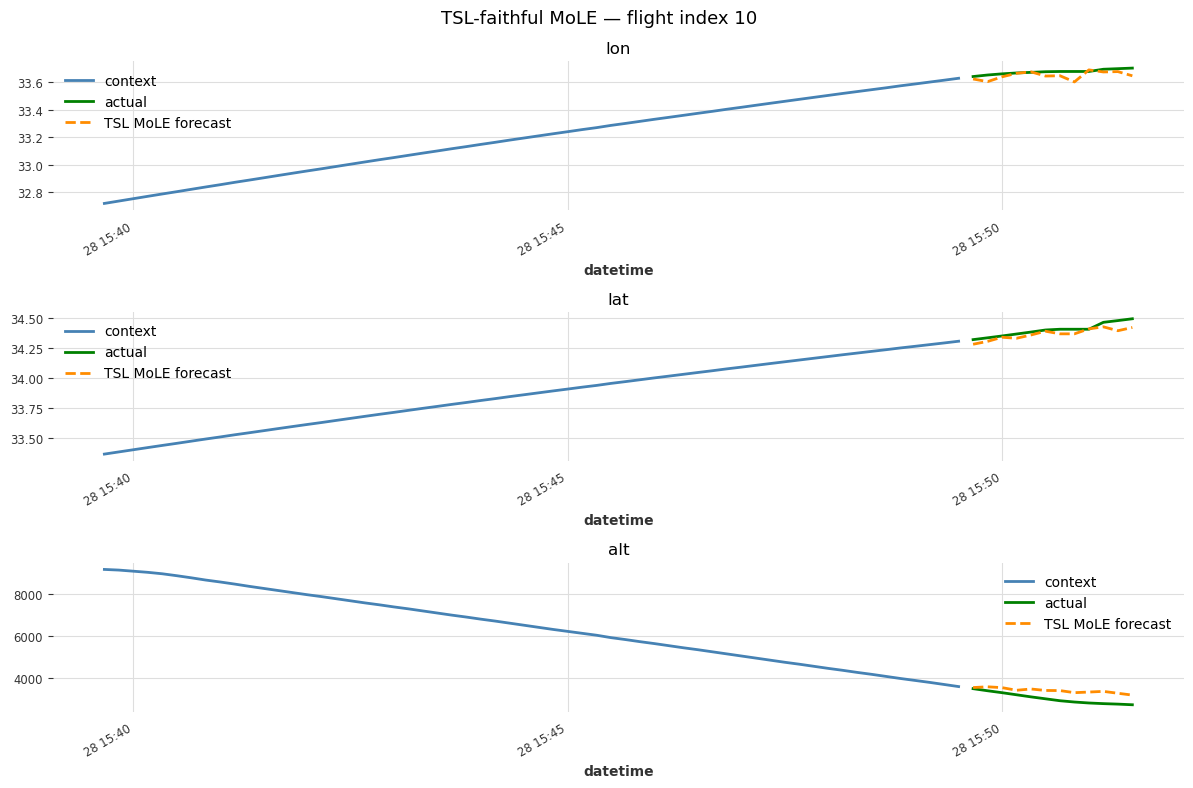

In [60]:
ctx_orig_tsl, act_orig_tsl, fct_orig_tsl = plot_forecast(model_tsl, SAMPLE_IDX, "TSL MoLE")

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
for ax, feat in zip(axes, feature_names):
    ctx_orig_tsl[feat].plot(ax=ax, label="context", color="steelblue")
    act_orig_tsl[feat].plot(ax=ax, label="actual", color="green")
    fct_orig_tsl[feat].plot(ax=ax, label="TSL MoLE forecast", color="darkorange", linestyle="--")
    ax.set_title(feat)
    ax.legend()

plt.suptitle(f"TSL-faithful MoLE — flight index {SAMPLE_IDX}", fontsize=13)
plt.tight_layout()
plt.show()

## 15. 2-D trajectory plot — TSL MoLE

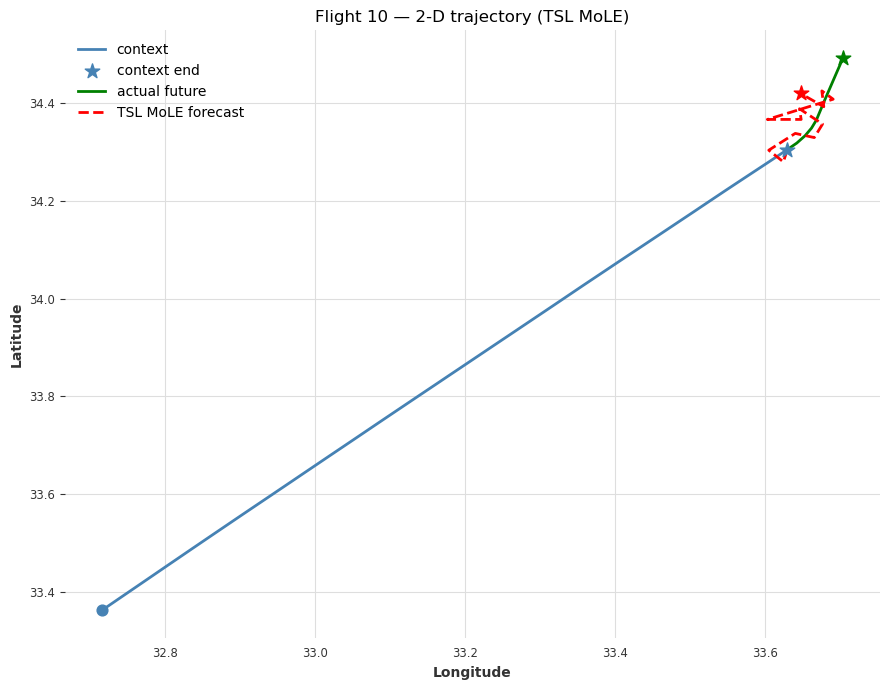

In [61]:
plot_2d(ctx_orig_tsl, act_orig_tsl, fct_orig_tsl, SAMPLE_IDX, "TSL MoLE")

## 16. 3-D trajectory plot — TSL MoLE

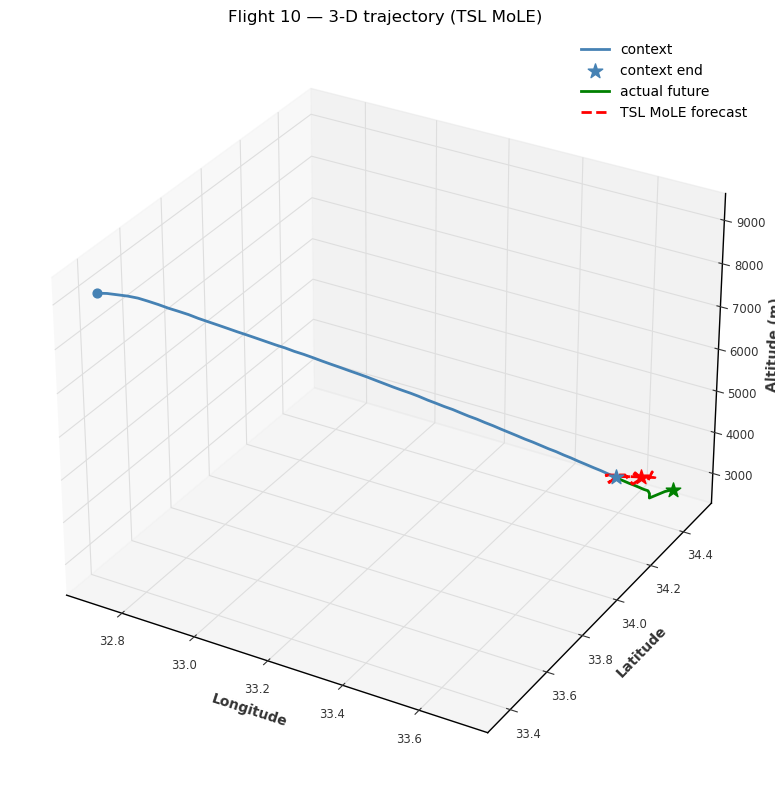

In [62]:
plot_3d(ctx_orig_tsl, act_orig_tsl, fct_orig_tsl, SAMPLE_IDX, "TSL MoLE")